In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

In [6]:
df = pd.read_csv(r"../../../data/raw/real-estate.csv")
print("Dimensions du dataset :", df.shape)
df.head()

Dimensions du dataset : (50, 5)


,Property_ID,Prix,Surface,Nb_Pieces,Age_Bien
0,P1,1386880,238,1,11
1,P2,804999,282,5,12
2,P3,631593,196,5,12
3,P4,2355723,125,2,28
4,P5,2548988,58,1,14


In [8]:
df.dtypes
features = [
    "Prix",
    "Surface",
    "Nb_Pieces",
    "Age_Bien"
]

X = df[features].copy()
X.head

<bound method NDFrame.head of        Prix  Surface  Nb_Pieces  Age_Bien
0   1386880      238          1        11
1    804999      282          5        12
2    631593      196          5        12
3   2355723      125          2        28
4   2548988       58          1        14
5    408940      248          2        20
6   1124926       77          3        15
7   1614093      255          2        21
8    685777      272          2        20
9   1973250      177          5        10
10  2948790      101          5        27
11  2229305      132          5         4
12  2946791      299          3         3
13   938873      160          5         2
14   365953      193          1        18
15  2897480      166          4        19
16   303267      118          1        24
17  2479897      148          1        17
18  2224596      189          5        14
19   457164       74          4         8
20   835626      229          4        16
21  2528636      172          4        13
22  

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape des données standardisées :", X_scaled.shape)

Shape des données standardisées : (50, 4)


In [21]:
results_k = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=42
    )
    labels = model.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    inertia = model.inertia_

    results_k.append({
        "K": k,
        "Silhouette": sil,
        "Davies_Bouldin": db,
        "Inertia": inertia
    })

results_k = pd.DataFrame(results_k)
results_k
##%%


,K,Silhouette,Davies_Bouldin,Inertia
0,2,0.249867,1.556317,145.930849
1,3,0.247327,1.233792,113.413156
2,4,0.277080,1.118595,90.210965
3,5,0.273232,1.061008,74.249073
4,6,0.266721,1.140645,65.011633
5,7,0.286818,0.957893,57.477183
6,8,0.284066,1.031208,51.562061


Meilleur K proposé automatiquement : 7


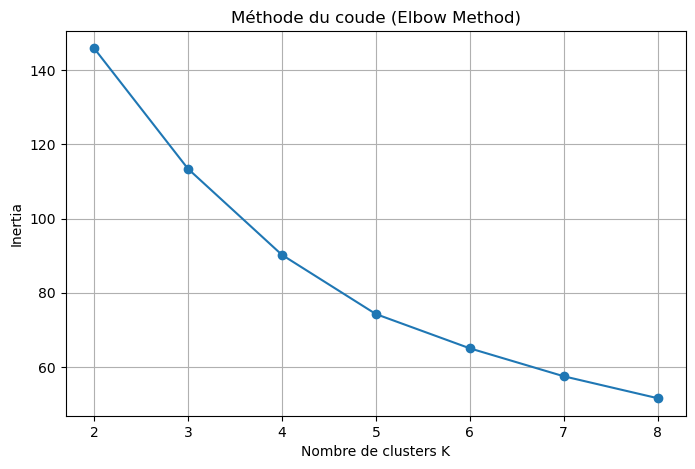

In [12]:
plt.plot(results_k["K"], results_k["Inertia"], marker="o")
plt.title("Méthode du coude (Elbow Method)")
plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertia")
plt.show()

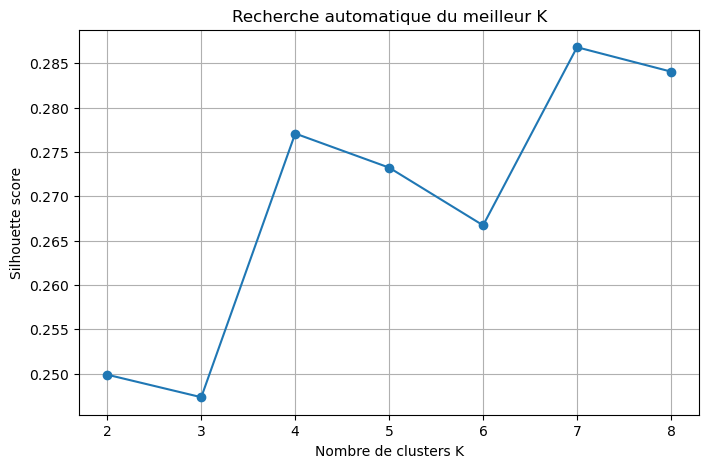

In [13]:
plt.plot(results_k["K"], results_k["Silhouette"], marker="o")
plt.title("Recherche automatique du meilleur K")
plt.xlabel("Nombre de clusters K")
plt.ylabel("Silhouette score")
plt.show()

In [37]:
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    n_init=20,
    random_state=42
)

labels_k = kmeans.fit_predict(X_scaled)
df["Cluster_KMeans"] = labels_k

df[["Property_ID", "Cluster_KMeans"]].head()

,Property_ID,Cluster_KMeans
0,P1,0
1,P2,4
2,P3,4
3,P4,2
4,P5,2


In [38]:
centroids_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=features)
centroids_scaled

,Prix,Surface,Nb_Pieces,Age_Bien
0,-0.793963,0.749913,-0.726900,0.285724
1,-0.791415,-1.427111,0.028321,-0.468516
2,0.263804,-0.675657,-1.167446,0.953269
3,1.382572,-0.027780,0.741585,0.667688
4,0.019237,0.563211,0.950562,-1.133668


In [39]:
centroids_real = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
).round(2)

centroids_real

,Prix,Surface,Nb_Pieces,Age_Bien
0,833571.25,238.75,2.00,17.58
1,835765.00,88.29,3.14,11.71
2,1744432.33,140.22,1.33,22.78
3,2707822.33,185.00,4.22,20.56
4,1533831.23,225.85,4.54,6.54


In [40]:
silhouette_final = silhouette_score(X_scaled, labels_k)
davies_final = davies_bouldin_score(X_scaled, labels_k)
inertia_final = kmeans.inertia_

print("Silhouette score     :", round(silhouette_final, 4))
print("Davies-Bouldin score :", round(davies_final, 4))
print("Inertia              :", round(inertia_final, 4))

Silhouette score     : 0.2732
Davies-Bouldin score : 1.061
Inertia              : 74.2491


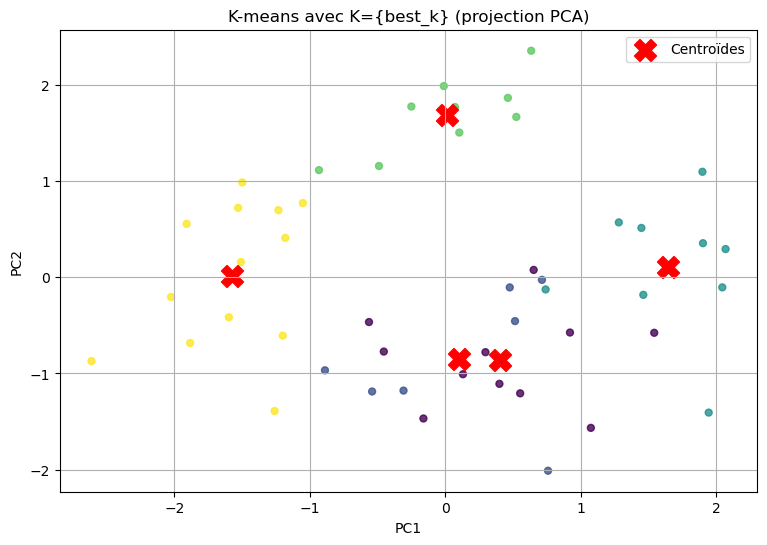

In [41]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_k, s=25, alpha=0.8)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    color="red",
    marker="X",
    s=250,
    label="Centroïdes"
)
plt.title(f"K-means avec K={{best_k}} (projection PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

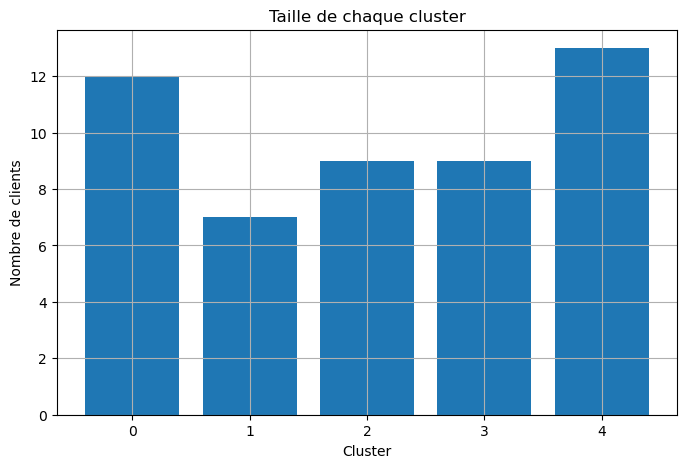

Cluster_KMeans
0    12
1     7
2     9
3     9
4    13
Name: count, dtype: int64

In [42]:
cluster_sizes = df["Cluster_KMeans"].value_counts().sort_index()

plt.bar(cluster_sizes.index.astype(str), cluster_sizes.values)
plt.title("Taille de chaque cluster")
plt.xlabel("Cluster")
plt.ylabel("Nombre de clients")
plt.show()

cluster_sizes

In [43]:
cluster_profile = df.groupby("Cluster_KMeans")[features].mean().round(2)
cluster_profile

,Prix,Surface,Nb_Pieces,Age_Bien
Cluster_KMeans,,,,
0,833571.25,238.75,2.00,17.58
1,835765.00,88.29,3.14,11.71
2,1744432.33,140.22,1.33,22.78
3,2707822.33,185.00,4.22,20.56
4,1533831.23,225.85,4.54,6.54


In [44]:
output_path = "result.csv"
df.to_csv(output_path, index=False)
print("Fichier sauvegardé :", output_path)

Fichier sauvegardé : result.csv
